# Narrative Arbitrage — a walk through one signal-day

This notebook runs the **entire pipeline for a single ticker on a single date**,
stopping at every stage to show what went in and what came out. It is the guided
tour of the system described in [`PLAN.md`](../PLAN.md).

**The thesis.** Each pre-market open we build two views of the day ahead:

| | sees | blind to |
|---|---|---|
| **Structure** (Kronos) | ~400 days of price/volume, nothing after `asof-1` | all news |
| **Narrative** (Claude) | overnight headlines | all prices |

We log where they **disagree**, and grade at the close which one was right.
**No trades, no PnL** — just tracked signals with honest confidence intervals.

**Worked example:** `NVDA`, `asof = 2025-05-29` — the morning after NVIDIA's
Q1 FY26 earnings. Kronos's context ends at the **2025-05-28 close**, *before* the
after-hours release, so structure is constitutionally blind to the single biggest
driver of the day. Narrative reads the earnings coverage. Classic setup.

In [1]:
import sys, os, json, shutil, pathlib
sys.path.insert(0, "..")

# Write to a scratch log so this walkthrough never touches the real immutable
# signal log. Must be set BEFORE importing anything from src.
DEMO_LOG = pathlib.Path("_out/demo_log").resolve()
if DEMO_LOG.exists():
    shutil.rmtree(DEMO_LOG)
DEMO_LOG.mkdir(parents=True)
os.environ["NARB_LOG_DIR"] = str(DEMO_LOG)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 90)

TICKER, ASOF = "NVDA", "2025-05-29"
print("ANTHROPIC_API_KEY set:", bool(os.getenv("ANTHROPIC_API_KEY")),
      "\n(if False, the LLM steps below run in a labelled MOCK mode)")
print("scratch log:", DEMO_LOG)

ANTHROPIC_API_KEY set: False 
(if False, the LLM steps below run in a labelled MOCK mode)
scratch log: /Users/isaac/Desktop/narrative arb/notebooks/_out/demo_log


## Step 1 — Data, and the no-lookahead rule

`load_context(ticker, asof)` returns the daily bars Kronos is **allowed** to see:
every bar strictly **before** `asof`. The first bar Kronos predicts is dated
`asof` itself. Source priority is Yahoo → Stooq → on-disk cache, and which source
answered is recorded.

In [2]:
from src.data import load_context, load_actual

pl = load_context(TICKER, ASOF)
print(f"source            : {pl.source}")
print(f"bars in context   : {len(pl.df)}")
print(f"first / last bar   : {pl.df.index.min().date()}  ->  {pl.last_context_date.date()}")
print(f"asof (bar 1 pred.) : {pl.asof}")
assert pl.last_context_date < pd.Timestamp(ASOF), "lookahead!"
pl.df.tail(3)

source            : cache
bars in context   : 120
first / last bar   : 2024-12-03  ->  2025-05-28
asof (bar 1 pred.) : 2025-05-29


,open,high,low,close,volume,amount
2025-05-23,129.818059,132.494301,128.979238,131.106247,198821300,2.596595e+10
2025-05-27,133.962247,135.470144,133.123426,135.310364,192953600,2.594580e+10
2025-05-28,135.839616,137.057910,134.601346,134.621323,304021100,4.120399e+10


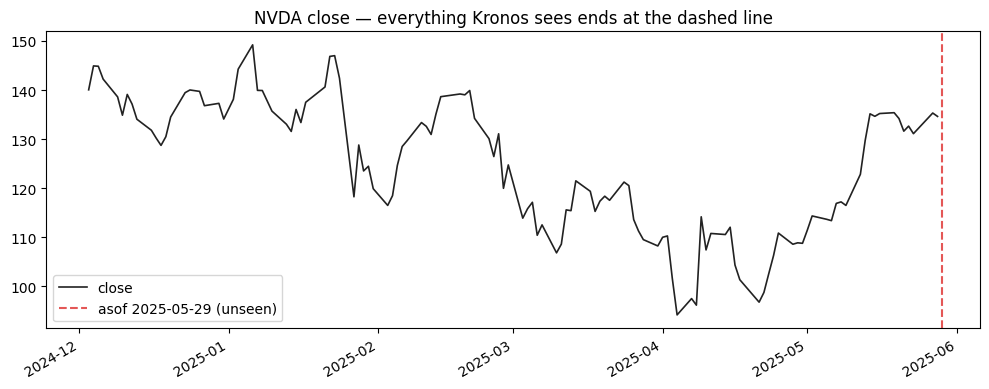

In [3]:
ax = pl.df["close"].iloc[-120:].plot(figsize=(10,4), color="#222", lw=1.2)
ax.axvline(pd.Timestamp(ASOF), color="#e45756", ls="--", label=f"asof {ASOF} (unseen)")
ax.set_title(f"{TICKER} close — everything Kronos sees ends at the dashed line")
ax.legend(); plt.tight_layout()

## Step 2 — Structure: Kronos, with the dispersion put back

Kronos is a decoder-only foundation model over tokenised K-lines. It is
probabilistic: `predict(..., sample_count=N)` runs N sampled autoregressive
paths.

**The gotcha.** Upstream `auto_regressive_inference` ends with
`preds = np.mean(preds, axis=1)` — it **averages the N paths** and returns one
smoothed mean line with *zero* dispersion. That kills the entire point.

**Our fix** (`src/kronos_infer.py :: _auto_regressive_paths`): the identical
batched inference, returning the array **before** the mean — shape
`(sample_count, pred_len, 6)`. One pass, full distribution, code we own.

In [4]:
from src.kronos_infer import forecast, fan_chart
from src.config import SAMPLE_COUNT, GRADE_BAR

fc = forecast(pl, sample_count=SAMPLE_COUNT)   # seed derived from (ticker, asof) -> reproducible
print("paths tensor shape (samples, horizon, OHLCV+amount):", fc.paths.shape)
print(f"prev_close (last seen)  : {fc.prev_close:.2f}")
print(f"graded bar              : {fc.y_index[GRADE_BAR-1].date()}")

/Users/isaac/Desktop/narrative arb/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


paths tensor shape (samples, horizon, OHLCV+amount): (200, 3, 6)
prev_close (last seen)  : 134.62
graded bar              : 2025-05-29


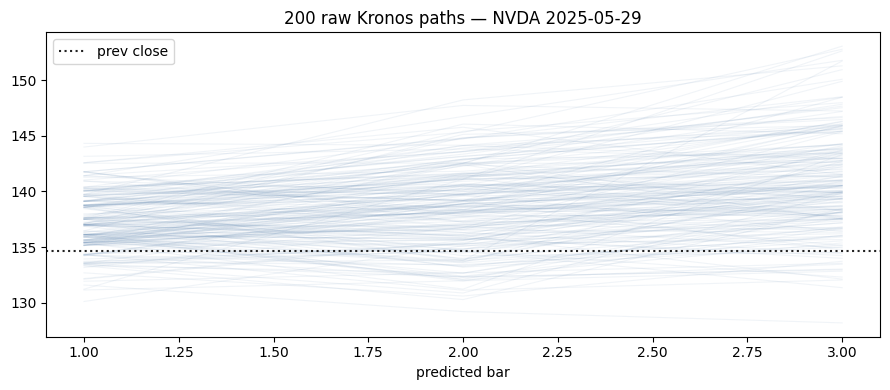

In [5]:
# raw sampled close trajectories — this is what "distribution" means here
close_paths = fc.paths[:, :, 3]
fig, ax = plt.subplots(figsize=(9,4))
for row in close_paths:
    ax.plot(range(1, close_paths.shape[1]+1), row, color="#4c78a8", alpha=0.08, lw=.8)
ax.axhline(fc.prev_close, color="#222", ls=":", label="prev close")
ax.set_xlabel("predicted bar"); ax.set_title(f"{SAMPLE_COUNT} raw Kronos paths — {TICKER} {ASOF}")
ax.legend(); plt.tight_layout()

median return : +1.79%
P(up)         : 85%
dispersion    : 1.93%   strength (median/sd): +0.93
quantiles     : {'5%': '-0.97%', '25%': '+0.62%', '50%': '+1.79%', '75%': '+3.34%', '95%': '+5.31%'}


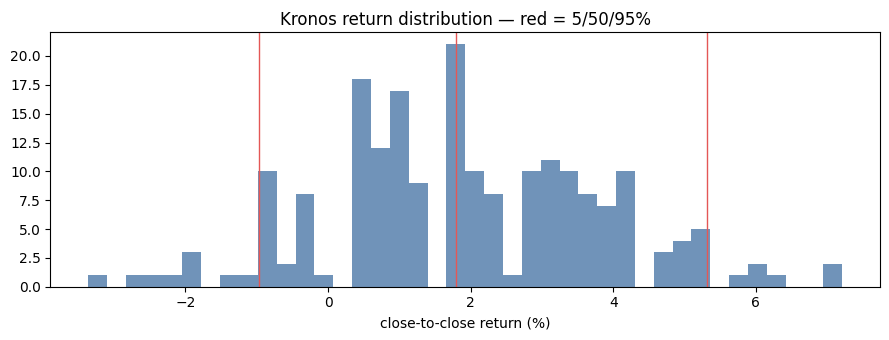

In [6]:
# the graded-bar close-to-close RETURN distribution
r = fc.ret_dist
q = fc.ret_quantiles()
print(f"median return : {fc.median_ret*100:+.2f}%")
print(f"P(up)         : {fc.p_up:.0%}")
print(f"dispersion    : {fc.std_ret*100:.2f}%   strength (median/sd): {fc.strength:+.2f}")
print("quantiles     :", {f"{int(k*100)}%": f"{v*100:+.2f}%" for k,v in q.items()})

fig, ax = plt.subplots(figsize=(9,3.5))
ax.hist(r*100, bins=40, color="#4c78a8", alpha=.8)
for k in (0.05, 0.5, 0.95):
    ax.axvline(q[k]*100, color="#e45756", lw=1)
ax.set_xlabel("close-to-close return (%)"); ax.set_title("Kronos return distribution — red = 5/50/95%")
plt.tight_layout()

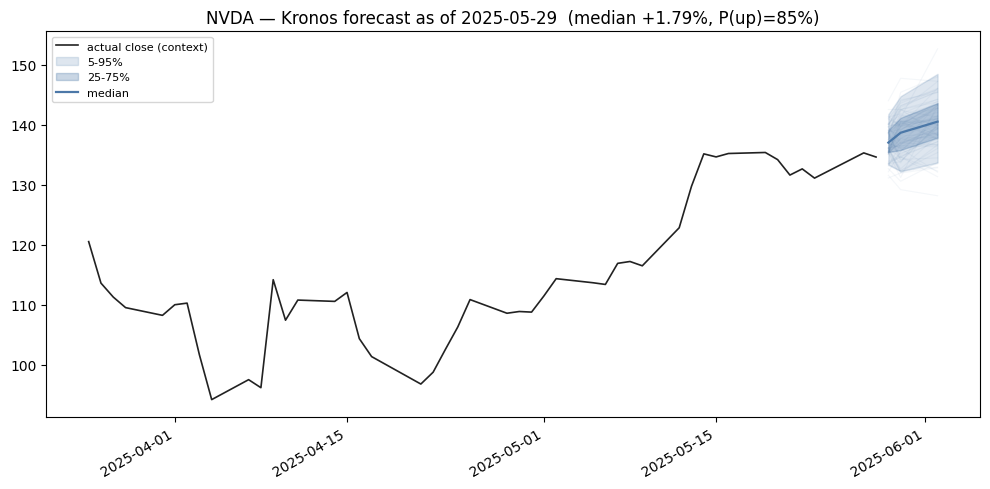

In [7]:
fig, ax = fan_chart(fc, context_bars=45)

## Step 3 — The headline sub-agent (LangGraph)

A small state machine, not a linear script: source selection branches on whether
`asof` is historical (curated + cited headlines) or live (nightly fetch), and a
"no material news" path short-circuits to a neutral narrative. It is
**price-blind** — it never fetches or stores a quote.

In [8]:
from src.headlines_agent import build_headlines_graph, get_headlines
print(build_headlines_graph().get_graph().draw_mermaid())

%%{init: {'flowchart': {'curve': 'linear'}}}%%
graph TD;
	__start__([<p>__start__</p>]):::first
	fetch(fetch)
	dedupe(dedupe)
	assess_materiality(assess_materiality)
	finalize(finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> fetch;
	dedupe --> assess_materiality;
	fetch --> dedupe;
	finalize --> __end__;
	assess_materiality -.-> finalize;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [9]:
hs = get_headlines(TICKER, ASOF)
print("mode        :", hs["mode"])
print("sources     :", hs["sources_used"])
print("no_news     :", hs["no_news"])
print("\nagent trace:")
for n in hs["notes"]:
    print("  -", n)
pd.DataFrame(hs["headlines"])[["source","published","title"]]

mode        : curated
sources     : ['curated:NVDA_2025-05-29.json']
no_news     : False

agent trace:
  - loaded 3 curated headlines
  - dedupe: 3 -> 3
  - materiality: kept 3/3 — All three headlines report material, price-relevant information: Q1 FY26 earnings beat with strong data-center growth (1), explicit forward guidance detailing a $8B China-related revenue headwind for Q2 (2), and a $4.5B charge tied to new U.S. export restrictions on H20 chips (3). These directly affect near-term financial results, regulatory exposure, and forward outlook.
  - FINAL: 3 material headlines


,source,published,title
0,CNBC,2025-05-28,Nvidia beats Q1 FY26 estimates; data-center revenue up 73% year over year
1,NVIDIA / Kiplinger live blog,2025-05-28,"Nvidia guides Q2 revenue to about $45.0B, excluding roughly $8B of lost H20 China sales"
2,CNBC / NVIDIA 10-Q,2025-05-28,Nvidia takes $4.5B charge on excess H20 inventory after April 2025 China export ban


## Step 4 — Narrative score (price-blind)

The scorer sees **only** the headline text above and returns a structured view
via an Anthropic tool call: `direction ∈ {bear, neutral, bull}`, `conviction 1-10`,
a rationale, and the drivers. `S_N = direction × conviction`.

**Honesty flag.** For a *historical* `asof` the model may carry the realised
outcome in its training data. That is undetectable, so we don't pretend to scrub
it — the row is flagged `llm_contaminated=True` and the **live run** is the real
test.

In [10]:
from src.narrative import score_narrative
sc = score_narrative(TICKER, hs["headlines"], ASOF)
print(json.dumps(sc.to_dict(), indent=2))
print(f"\nS_N (direction x conviction) = {sc.signal}")

{
  "ticker": "NVDA",
  "asof": "2025-05-29",
  "direction": "bull",
  "conviction": 7,
  "rationale": "Nvidia's fiscal Q1 beat on both revenue and EPS, with data-center revenue up 73% y/y, underscoring continued AI demand strength; shares reacted higher in after-hours trading on the print. This positive core beat is partially offset by the $4.5B charge on excess H20 inventory and the ~$8B China revenue headwind baked into Q2 guidance, but the underlying business momentum and forward $45B guide (ex-China impact) signal robust demand outside the restricted segment.",
  "key_drivers": [
    "Q1 FY26 revenue and EPS beat",
    "Data-center revenue +73% YoY",
    "Q2 guidance ~$45B despite $8B H20 China exclusion",
    "$4.5B charge on H20 inventory from export ban",
    "After-hours share strength on earnings"
  ],
  "material_news": true,
  "headline_count": 3,
  "llm_contaminated": true,
  "model": "claude-sonnet-5",
  "mocked": false
}

S_N (direction x conviction) = 7


## Step 5 — Divergence verdict (v1)

The **classification is deterministic** and grounded only in the two signals'
numbers (`PLAN §6`):

- **Directional** — `sign(S_N) ≠ sign(median r)` and narrative conviction ≥ 4.
- **Magnitude** — narrative conviction ≥ 7 **and** `P(return in narrative's
  direction) < 30%` under Kronos (structure thinks the narrative's move is
  unlikely).

The **brief** is an LLM call constrained to those numbers — it explains the
disagreement to a PM, it does not add a new opinion.

In [11]:
from src.divergence import assess
div = assess(sc, fc, brief=True)
print(f"structure direction : {div.struct_dir:+d}   (median {div.struct_median*100:+.2f}%)")
print(f"narrative direction : {div.narr_dir:+d}   (conviction {sc.conviction})")
print(f"P(move in narrative's direction | structure): {div.p_narr_direction:.0%}")
print(f"\n==> divergence_type: {div.divergence_type}\n")
print("PM brief:\n" + div.brief)

structure direction : +1   (median +1.79%)
narrative direction : +1   (conviction 7)
P(move in narrative's direction | structure): 85%

==> divergence_type: aligned

PM brief:
STRUCTURE, based purely on price/volume history, projects a bullish session for NVDA: median close-to-close +1.79%, 85% probability of an up close, strength +0.93 sd, with a 5-95% band of -0.97% to +5.31%. NARRATIVE, reading three overnight headlines, is also bullish (conviction 7/10), citing the fiscal Q1 beat on revenue and EPS, data-center revenue up 73% y/y, and after-hours share strength, tempered by an $8B China revenue headwind and a $4.5B H20 inventory charge embedded in Q2 guidance. The two signals are aligned, with an 85% structural probability of the move matching narrative direction. Resolution at the close: whether NVDA closes up, and specifically whether the gain falls within the -0.97% to +5.31% band, versus a close below it or negative.


## Step 6 — Lock it (immutable log)

The signal is written as one line to an append-only JSONL. Each line's `row_hash`
is chained off the previous line's hash, so any later edit to history breaks the
chain. Git history of that file is the external tamper-evidence.

In [12]:
from src.store import append_signal, verify_chain, SIGNALS_JSONL, load_signals, ImmutableViolation
from src.config import QUANTILES
rq = fc.ret_quantiles(QUANTILES)
rec = dict(asof=ASOF, ticker=TICKER, llm_contaminated=sc.llm_contaminated,
           price_source=pl.source, context_to=str(pl.last_context_date.date()),
           prev_close=fc.prev_close,
           kronos_q05=rq[.05], kronos_q25=rq[.25], kronos_q50=rq[.5],
           kronos_q75=rq[.75], kronos_q95=rq[.95],
           kronos_p_up=fc.p_up, kronos_std=fc.std_ret, kronos_strength=fc.strength,
           narr_dir=sc.dir_int, narr_conviction=sc.conviction, narr_rationale=sc.rationale,
           narr_signal=sc.signal, divergence_type=div.divergence_type,
           divergence_verdict="pending", brief=div.brief)
try:
    row = append_signal(rec)
    print("locked. row_hash:", row["row_hash"][:16], "…")
except ImmutableViolation as e:
    print("already locked (that's the point):", e)

# a second attempt is refused — the row is immutable
try:
    append_signal({**rec, "kronos_q50": 0.0})
except ImmutableViolation as e:
    print("second write refused:", e)

print("chain verifies:", verify_chain(SIGNALS_JSONL))
load_signals().query("ticker == @TICKER").T

locked. row_hash: 8c1bc71d910b1ed3 …
second write refused: signal for ('2025-05-29', 'NVDA') already locked; not overwriting
chain verifies: True


,0
asof,2025-05-29
ticker,NVDA
gen_ts,NaN
llm_contaminated,True
price_source,cache
context_from,NaN
context_to,2025-05-28
prev_close,134.621323
kronos_q05,-0.009669
kronos_q25,0.006178


## Step 7 — Grade at the close (next morning)

The second graph joins the locked signal with the **settled** close: was the
actual return inside Kronos's 5-95 envelope? Did each side call the direction?
On divergence rows, which side won?

In [13]:
from src.evaluate import run as run_eval, report
a = load_actual(TICKER, ASOF)
print(f"prev close  : {a.prev_close:.2f}")
print(f"actual close: {a.actual_close:.2f}")
print(f"realised return (close-to-close): {a.ret*100:+.2f}%")

run_eval(ASOF)
from src.store import joined
row = joined().query("ticker == @TICKER and asof == @ASOF").iloc[0]
row[["ret","kronos_q05","kronos_q50","kronos_q95","inside_envelope",
     "dir_match_struct","dir_match_narr","divergence_type","divergence_outcome"]]

prev close  : 134.62
actual close: 139.00
realised return (close-to-close): +3.25%


ret                    0.03249
kronos_q05           -0.009669
kronos_q50            0.017884
kronos_q95            0.053102
inside_envelope           True
dir_match_struct          True
dir_match_narr            True
divergence_type        aligned
divergence_outcome         n/a
Name: 0, dtype: object

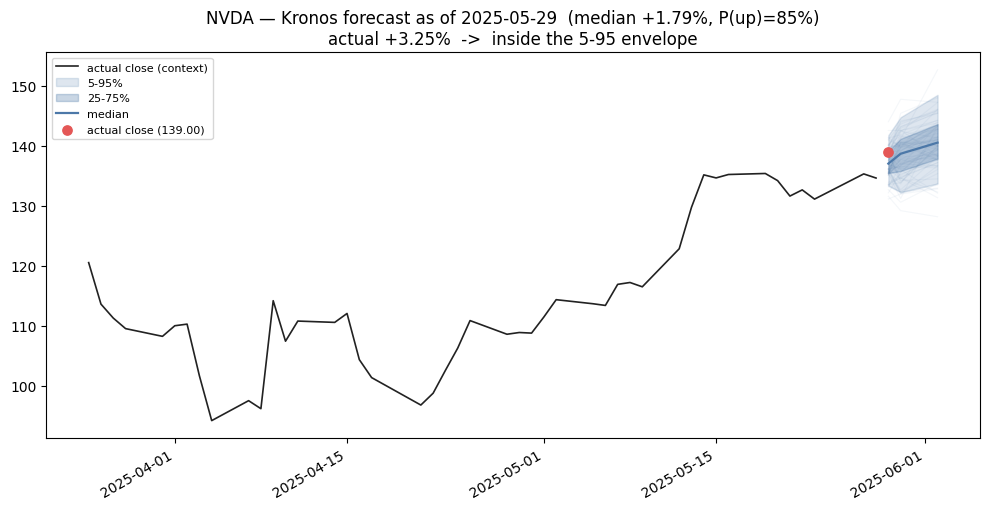

In [14]:
fig, ax = fan_chart(fc, actual_close=a.actual_close, context_bars=45)
_ = ax.set_title(ax.get_title() + f"\nactual {a.ret*100:+.2f}%  ->  "
                 f"{'inside' if row['inside_envelope'] else 'OUTSIDE'} the 5-95 envelope")

### Reading this example

Kronos, blind to the earnings, still leaned bullish — NVDA went in on strong
recent momentum, and the model extrapolated it. The realised close-to-close move
landed **inside** the envelope. That makes this an *aligned* day, not the
"narrative sees what structure can't" divergence the setup invites — which is
exactly why the plan says *confirm with the run, don't assume*. An honest null is
still a result: it tells you how much dispersion Kronos already prices in around
a known event date.

## Step 8 — The whole thing, one call

Everything above is the `src/graph.py` LangGraph. In production the nightly job
just calls `run_universe(asof)` over all 12 tickers.

In [15]:
from src.graph import build_graph, run_ticker
print(build_graph().get_graph().draw_mermaid())

%%{init: {'flowchart': {'curve': 'linear'}}}%%
graph TD;
	__start__([<p>__start__</p>]):::first
	load_prices(load_prices)
	run_kronos(run_kronos)
	run_headlines(run_headlines)
	score_narrative(score_narrative)
	assess_divergence(assess_divergence)
	persist(persist)
	handle_error(handle_error)
	__end__([<p>__end__</p>]):::last
	__start__ --> load_prices;
	assess_divergence --> persist;
	handle_error --> __end__;
	persist --> __end__;
	run_headlines --> score_narrative;
	run_kronos --> run_headlines;
	score_narrative --> assess_divergence;
	load_prices -.-> run_kronos;
	load_prices -.-> handle_error;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [16]:
res = run_ticker(TICKER, ASOF, allow_replace=True)   # replace: re-run the same day in the notebook
from src.graph import _summary_row
print(_summary_row(res))
print("\n--- running report (all locked signal-days) ---")
print(report())

NVDA    struct +1.79%  P(up)  85%   narr    bull/7   => aligned

--- running report (all locked signal-days) ---
graded signal-days: 1  (1 tickers, 1 dates)
  envelope coverage (target ~90%): 100%
  structure direction hit:         100%
  narrative direction hit:         100%
  no divergence rows yet


## What the month-long live run adds

This one row is an illustration. The pilot logs ~20 trading days × 12 tickers ≈
**240 signal-days**, all dated *after* the model's knowledge cutoff so narrative
is genuinely blind. Then `evaluate.report()` gives:

- **envelope coverage** (well-calibrated ⇒ ~90%),
- **direction hit rate** for each side (baseline 50%),
- **divergence-conditioned win rate** — the headline research question — with
  Wilson confidence intervals, and the honest caveat that n is small and
  cross-sectionally correlated.

Non-goals stay non-goals: no position sizing, no PnL, no alpha claim.